# PSP Model Visualizers

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from neurodsp.sim.transients import sim_synaptic_kernel
from neurodsp.sim.aperiodic import sim_synaptic_current, sim_poisson_pop

from neurodsp.spectral.power import compute_spectrum, compute_spectrum_fft

from neurodsp.plts.spectral import plot_power_spectra
from neurodsp.plts.time_series import plot_time_series, plot_multi_time_series

from spiketools.sim.train import sim_spiketrain_poisson

In [2]:
# Import custom code
from vcode.plts import plot_spectra, plot_bar
from vcode.gif import clear_output, animate_plot
from vcode.utils import incrementer

## Run Settings

In [42]:
SAVE = False

## Plot Functions

In [3]:
def plot_kernels(ampa, gaba, ax=None):
    """Plot kernels."""
    
    if not ax:
        _, ax = plt.subplots(figsize=(3.5, 3))
        
    ax.plot(ampa, color=COLORS['ampa'], label='AMPA (Exc)')
    ax.plot(gaba, color=COLORS['gaba'], label='GABA (Inh)')
    ax.spines['bottom'].set_position('center')
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend()

## General Visualization Settings

In [4]:
COLORS = {
    'ampa' : '#125FDB',
    'gaba' : '#F23029',
    'comb' : 'black',
}

In [5]:
TEXT_KWARGS = {                          
    'horizontalalignment' : 'center',
    'verticalalignment' : 'center',
}

## Simulate Kernels

In [6]:
# General Settings
kernel_length = 0.100    # 50 ms
fs = 10000

In [7]:
# AMPA kernel
ampa_rise  = 0.0001      # 0.1 ms
ampa_decay = 0.0020      # 2 ms

# GABA kernel
gaba_rise  = 0.0005      # 0.5 ms
gaba_decay = 0.0100      # 10 ms

In [8]:
# Generate and normalize a 
ampa_kernel = sim_synaptic_kernel(kernel_length, fs, ampa_rise, ampa_decay)
ampa_kernel_norm = ampa_kernel / np.max(ampa_kernel)

# Generate and normalize a GABA kernel
gaba_kernel = -sim_synaptic_kernel(kernel_length, fs, gaba_rise, gaba_decay) * 2
gaba_kernel_norm = -gaba_kernel / np.min(gaba_kernel)

### Kernel Plot

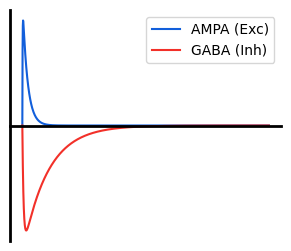

In [9]:
# Plot normalized kernels
plot_kernels(ampa_kernel_norm[0:2000], gaba_kernel_norm[0:2000])

### Kernel Power Spectra

In [12]:
# Compute the power spectra of the kernels
freqs, powers_ampa_kernel = compute_spectrum_fft(ampa_kernel, fs)
freqs, powers_gaba_kernel = compute_spectrum_fft(gaba_kernel, fs)

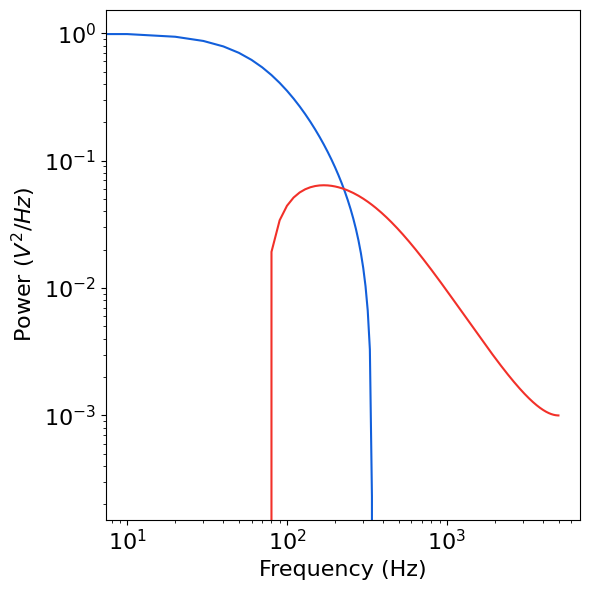

In [13]:
# Plot the power spectra of the kernels
plot_power_spectra(freqs, [powers_ampa_kernel, powers_gaba_kernel],
                   colors=[COLORS['ampa'], COLORS['gaba']])

## PSP Time Series

In [30]:
rate_ampa = 5
rate_gaba = 5
n_seconds = 2
refractory = len(ampa_kernel)
#refractory = 25

In [31]:
ev_ampa = sim_spiketrain_poisson(rate_ampa, n_seconds * fs, fs, refractory=refractory)
ev_gaba = sim_spiketrain_poisson(rate_gaba, n_seconds * fs, fs, refractory=refractory)

In [32]:
ampa_sig = np.convolve(ev_ampa, ampa_kernel)
gaba_sig = np.convolve(ev_gaba, gaba_kernel)

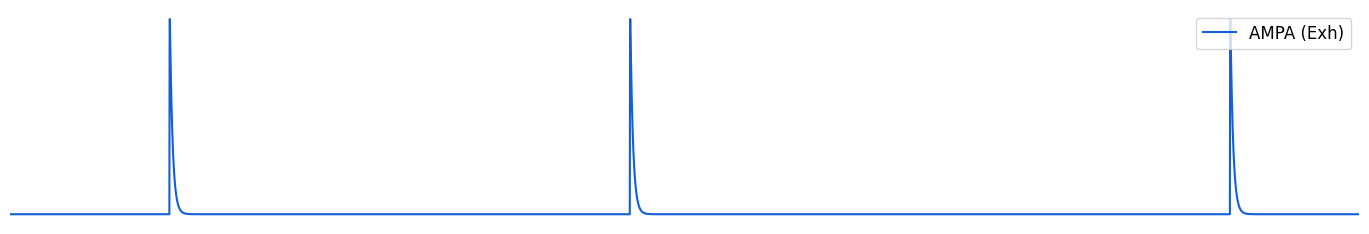

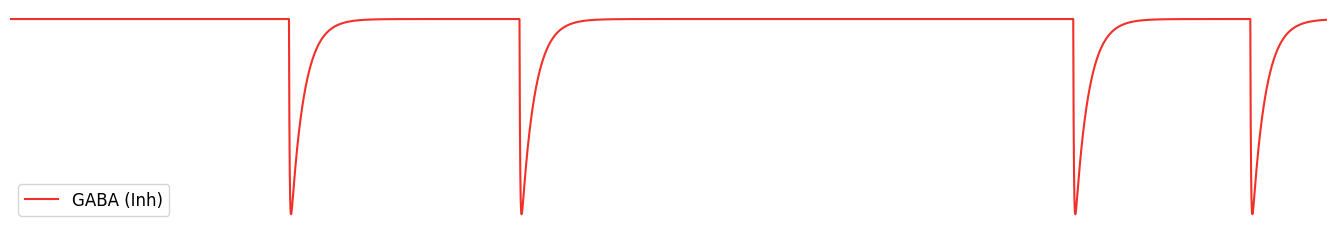

In [33]:
plot_time_series(None, ampa_sig, xlim=[0, fs], colors=COLORS['ampa'], labels='AMPA (Exh)')
plt.gca().axis('off');
plot_time_series(None, gaba_sig, xlim=[0, fs], colors=COLORS['gaba'], labels='GABA (Inh)')
plt.gca().axis('off');

In [34]:
comb_sig = ampa_sig + gaba_sig

In [35]:
np.min(comb_sig), np.max(comb_sig)

(-0.017085383736046577, 0.04285555304221437)

In [36]:
ts_ylim = [-0.02, 0.05]

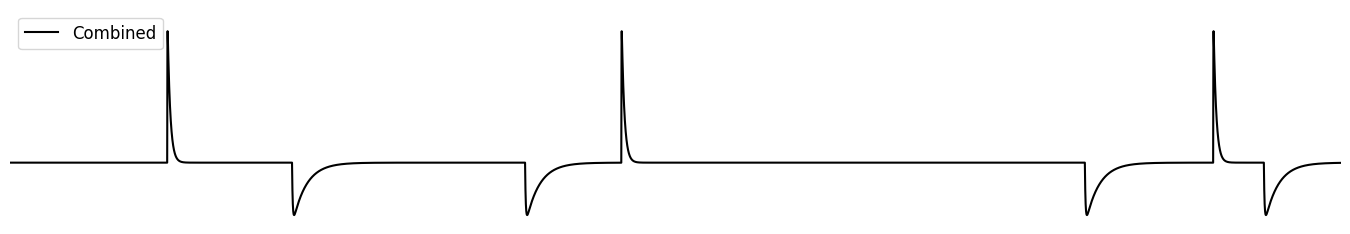

In [37]:
plot_time_series(None, comb_sig, xlim=[0, fs], labels='Combined', ylim=ts_ylim)
plt.gca().axis('off');

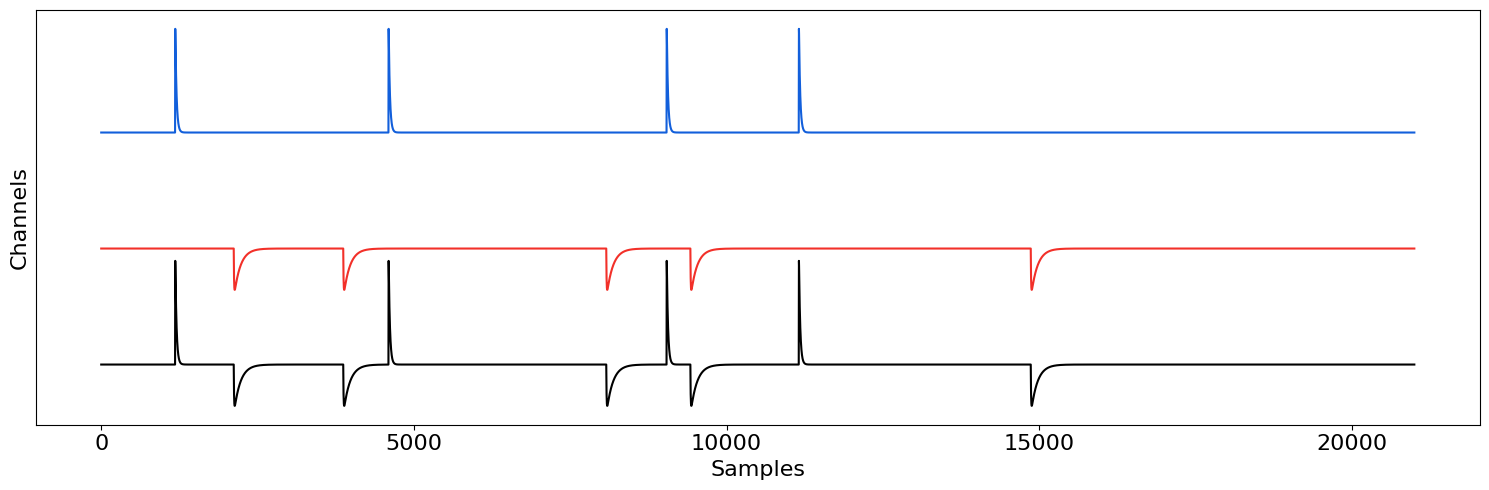

In [38]:
plot_multi_time_series(None, [comb_sig, gaba_sig, ampa_sig],
                       colors=[COLORS['comb'], COLORS['gaba'], COLORS['ampa']])

In [39]:
freqs_sig, powers_comb = compute_spectrum(comb_sig, fs, nperseg=fs/10)

In [40]:
np.min(powers_comb), np.max(powers_comb)
psd_ylim = [5.0e-12, 1e-06]

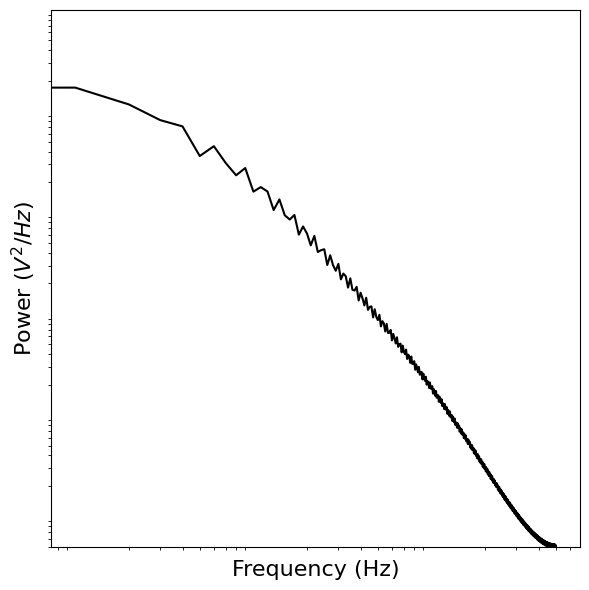

In [41]:
plot_power_spectra(freqs_sig, powers_comb, colors=COLORS['comb'],
                   xticks=[], yticks=[], ylim=psd_ylim)

## Set Up Gif-1

In [43]:
ei_img = plt.imread('img/EIsim.png')

def make_axes(add_top_panels=True, add_bottom_panels=True):
    
    fig = plt.figure(figsize=(8, 3), constrained_layout=True)
    gs = fig.add_gridspec(2, 6, hspace=0.15, wspace=0.5)

    axes = {}
    
    # Top Right - GIF text
    axes['tr_text'] = fig.add_subplot(gs[0, 0])
    axes['tr_text'].axis('off')
    if add_top_panels:
        axes['tr_text'].text(0.5, 0.6, 'PSP\nModel', fontsize=18, **TEXT_KWARGS)
    
    axes['tm_schem'] = fig.add_subplot(gs[0, 1:4])
    axes['tm_schem'].axis('off')
    if add_top_panels:
        axes['tm_schem'].imshow(ei_img)

    axes['tl_kern'] = fig.add_subplot(gs[0, 4:])
    if add_top_panels:
        plot_kernels(ampa_kernel_norm[0:2000], gaba_kernel_norm[0:2000], ax=axes['tl_kern'])
    else:
        axes['tl_kern'].axis('off')

    axes['bl_ts'] = fig.add_subplot(gs[1, 0:4])
    axes['bl_ts'].axis('off')
    axes['br_psd'] = fig.add_subplot(gs[1, 4:])
    
    if not add_bottom_panels:
        axes['br_psd'].axis('off')
    
    return fig, axes

## Example Plot

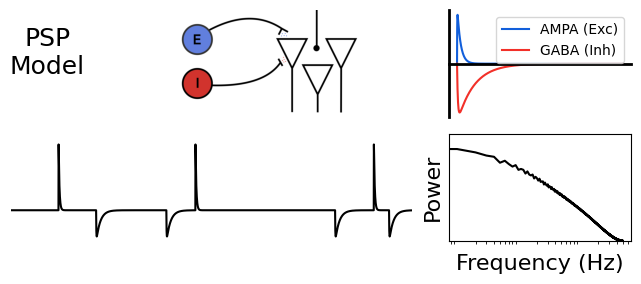

In [44]:
fig, axes = make_axes(add_top_panels=True)
plot_time_series(None, comb_sig,
                 xlim=[0, fs],
                 xticks=[], yticks=[], ylim=ts_ylim, ax=axes['bl_ts'])
plot_power_spectra(freqs_sig, powers_comb, colors=COLORS['comb'], ylim=psd_ylim,
                   xticks=[], yticks=[], ylabel='Power', ax=axes['br_psd'])

#fig.savefig('test2.pdf', bbox_inches="tight", dpi=300, transparent=True)

In [45]:
n_seconds = 1.5

rate1 = 0 
rate2 = 5
rate3 = 10
rate4 = 20

refractory1 = len(ampa_kernel) / 2
refractory2 = int(refractory1 / 2)
refractory3 = int(refractory2 / 2)
refractory4 = int(refractory3 / 2)

In [46]:
events_ampa = np.hstack([
    sim_spiketrain_poisson(rate1, int(1 * fs), fs, refractory=refractory1),
    sim_spiketrain_poisson(rate2, int(n_seconds * fs), fs, refractory=refractory2),
    sim_spiketrain_poisson(rate3, int(n_seconds * fs), fs, refractory=refractory3),
    sim_spiketrain_poisson(rate4, int(n_seconds * fs), fs, refractory=refractory4),
])

events_gaba = np.hstack([
    sim_spiketrain_poisson(rate1, int(1 * fs), fs, refractory=refractory1),
    sim_spiketrain_poisson(rate2, int(n_seconds * fs), fs, refractory=refractory2),
    sim_spiketrain_poisson(rate3, int(n_seconds * fs), fs, refractory=refractory3),
    sim_spiketrain_poisson(rate4, int(n_seconds * fs), fs, refractory=refractory4),
])

In [ ]:
ampa_sig = np.convolve(events_ampa, ampa_kernel)
gaba_sig = np.convolve(events_gaba, gaba_kernel)
comb_sig = ampa_sig + gaba_sig

## Builder Function

In [58]:
def build_all(sig, fs, sleep=0.025, save=False):
    
    start_ind = 0
    step_size = 250
    ts_len = fs
    
    n_steps = int(np.floor((len(comb_sig) - ts_len) / 250))
    
    fig, axes = make_axes(add_top_panels=True, add_bottom_panels=False)
    animate_plot(fig, save, 0, 'psp_model', sleep)
    
    ind = incrementer(start=1)
    for tstep in range(n_steps):
        
        clear_output(wait=True)
        
        fig, axes = make_axes(add_top_panels=True if not save else True)
        
        extracted = comb_sig[int(start_ind + tstep * step_size):int(fs + (tstep * step_size))]
        
        plot_time_series(None, extracted,
                         xticks=[], yticks=[], ylim=ts_ylim, ax=axes['bl_ts'])
        
        freqs_sig, powers_comb = compute_spectrum(extracted, fs, nperseg=fs/5)
        plot_power_spectra(freqs_sig, powers_comb, colors=COLORS['comb'], ylim=psd_ylim,
                           xticks=[], yticks=[], ylabel='Power', ax=axes['br_psd'])
        
        animate_plot(fig, save, next(ind), 'psp_model', sleep)

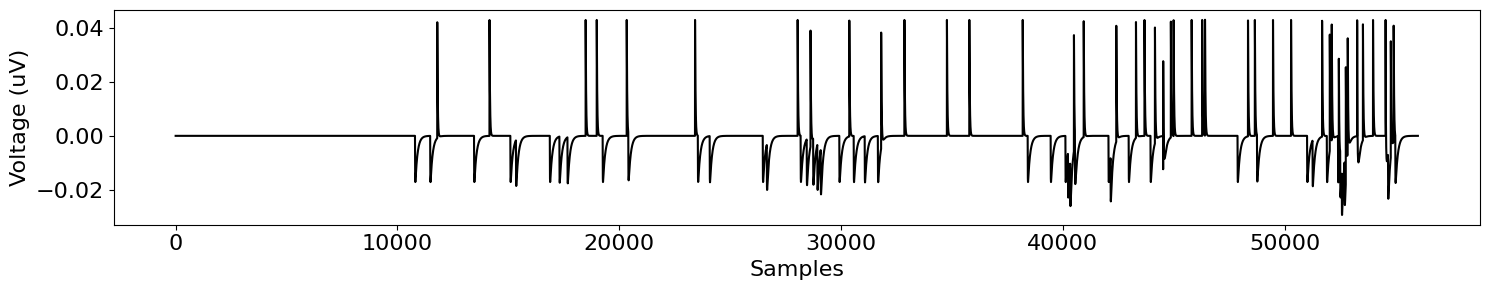

In [59]:
plot_time_series(None, comb_sig)

In [61]:
#build_all(comb_sig, fs, save=SAVE)

## Synaptic Current

In [62]:
# sim_poisson_pop(1, 100, n_neurons=1, firing_rate=1)

In [63]:
xlim = [500, 15000]

In [64]:
ampa_rate = 1
gaba_rate = 1

In [65]:
ampa_current = sim_synaptic_current(30, fs, tau_r=ampa_rise, tau_d=ampa_decay, firing_rate=ampa_rate)
gaba_current = sim_synaptic_current(30, fs, tau_r=gaba_rise, tau_d=gaba_decay, firing_rate=gaba_rate)

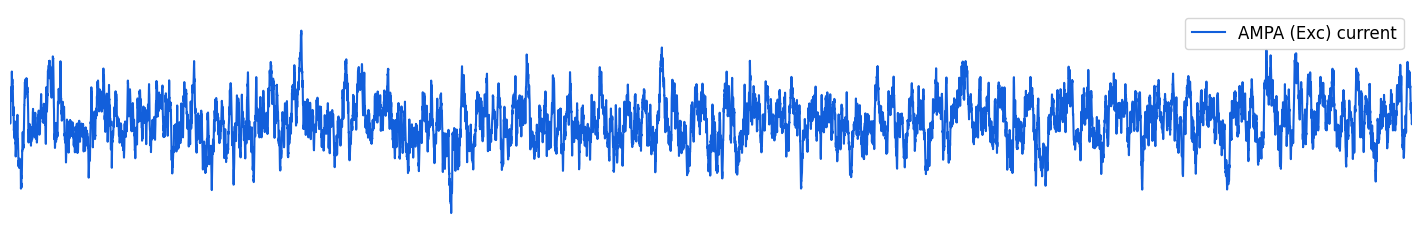

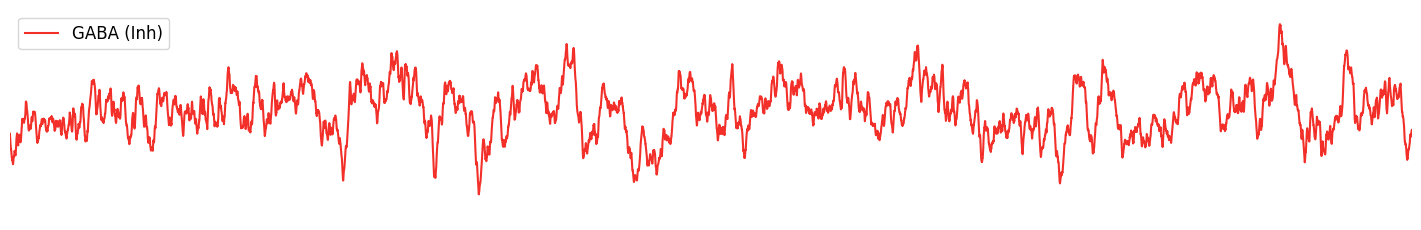

In [66]:
plot_time_series(None, ampa_current, colors=COLORS['ampa'], xlim=xlim, labels='AMPA (Exc) current')
plt.gca().axis('off');
plot_time_series(None, gaba_current, colors=COLORS['gaba'], xlim=xlim, labels='GABA (Inh)')
plt.gca().axis('off');

In [67]:
ei_ratio = 0.5

In [68]:
combined_sig = (1 - (1/ei_ratio) * ampa_current) + (1/ei_ratio * gaba_current)

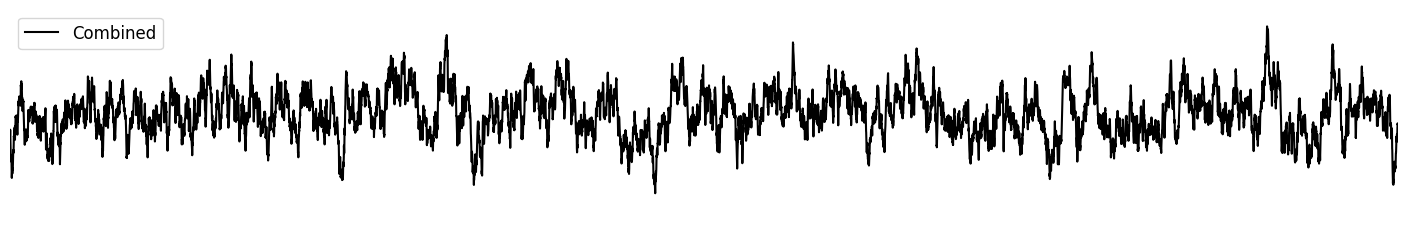

In [104]:
plot_time_series(None, combined_sig, xlim=xlim, labels='Combined')
plt.gca().axis('off');

In [109]:
plot_multi_time_series?

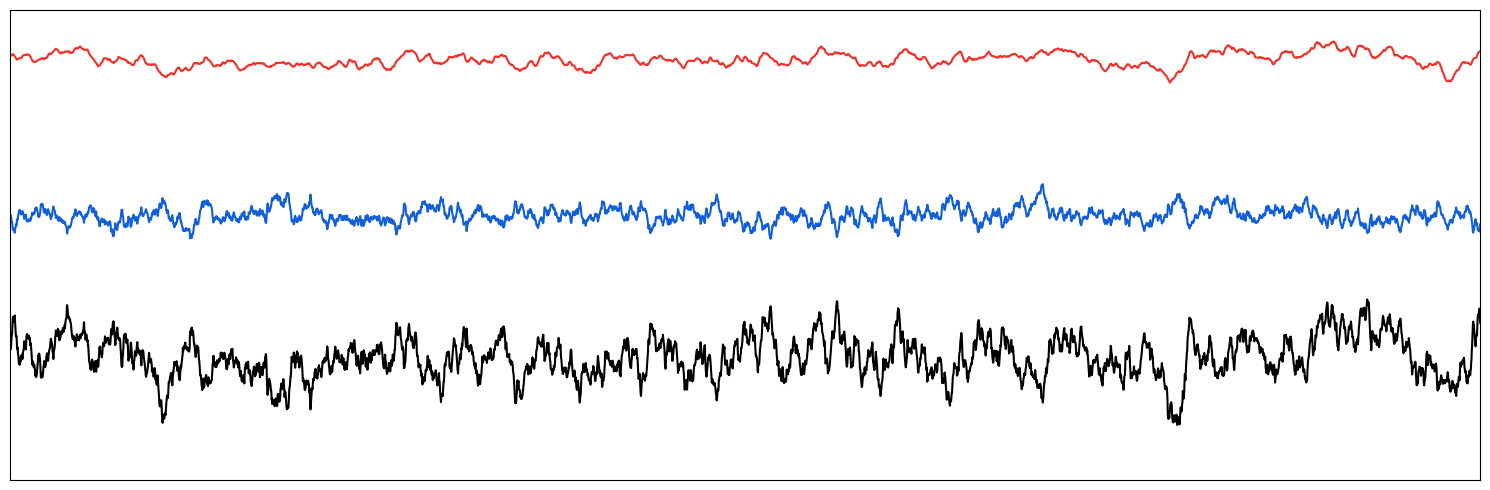

In [105]:
plot_multi_time_series(None, [combined_sig, ampa_current, gaba_current],
                       xlim=[0, 5000], xlabel=None, ylabel=None, xticks=[],
                       colors=[COLORS['comb'], COLORS['ampa'], COLORS['gaba']])

### XX

In [106]:
freqs_cur, powers_ampa_cur = compute_spectrum(ampa_current, fs)
freqs_cur, powers_gaba_cur = compute_spectrum(gaba_current, fs)
freqs_cur, powers_combined_cur = compute_spectrum(combined_sig, fs)

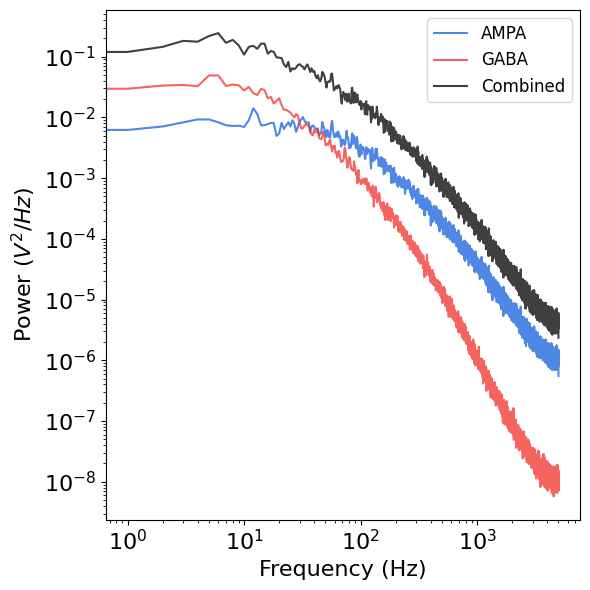

In [107]:
plot_power_spectra(freqs_cur, [powers_ampa_cur, powers_gaba_cur, powers_combined_cur], 
                   colors=[COLORS['ampa'], COLORS['gaba'], COLORS['comb']], alpha=0.75, 
                   labels=['AMPA', 'GABA', 'Combined'])

## Set up gif 2

In [124]:
ei_img = plt.imread('img/EIsim.png')

def make_axes2(add_top_panels=True, add_bottom_panels=True):
    
    fig = plt.figure(figsize=(10, 4), constrained_layout=True)
    gs = fig.add_gridspec(3, 6, hspace=0.15, wspace=0.5)

    axes = {}
    
    # Top Right - GIF text
    axes['tr_text'] = fig.add_subplot(gs[0, 0])
    axes['tr_text'].axis('off')
    if add_top_panels:
        axes['tr_text'].text(0.5, 0.6, 'PSP\nModel', fontsize=18, **TEXT_KWARGS)
    
    axes['tm_schem'] = fig.add_subplot(gs[0, 1:4])
    axes['tm_schem'].axis('off')
    if add_top_panels:
        axes['tm_schem'].imshow(ei_img)

    axes['tl_kern'] = fig.add_subplot(gs[0, 4:])
    if add_top_panels:
        plot_kernels(ampa_kernel_norm[0:2000], gaba_kernel_norm[0:2000], ax=axes['tl_kern'])
    else:
        axes['tl_kern'].axis('off')

    axes['bl_ts'] = fig.add_subplot(gs[1:, 0:4])
    axes['bl_ts'].axis('off')
    axes['br_psd'] = fig.add_subplot(gs[1:, 4:])
    
    if not add_bottom_panels:
        axes['br_psd'].axis('off')
    
    return fig, axes

In [125]:
axes

{'tr_text': <Axes: >,
 'tm_schem': <Axes: >,
 'tl_kern': <Axes: >,
 'bl_ts': <Axes: >,
 'br_psd': <Axes: xlabel='Frequency (Hz)', ylabel='Power'>}

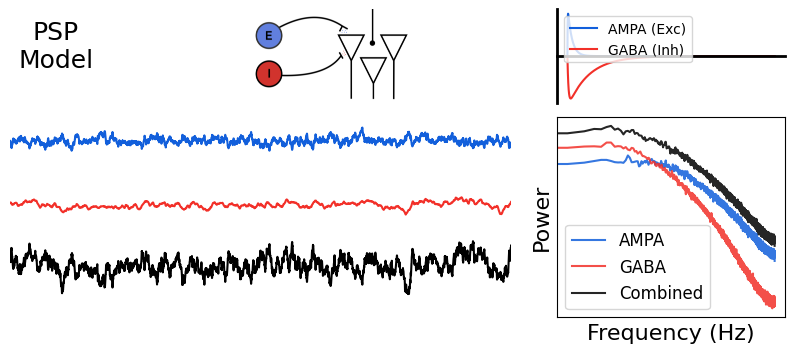

In [126]:
fig, axes = make_axes2()
plot_multi_time_series(None, [combined_sig, gaba_current, ampa_current],
                       xlim=[0, 5000], xlabel=None, ylabel=None, xticks=[],
                       colors=[COLORS['comb'], COLORS['gaba'], COLORS['ampa']], ax=axes['bl_ts'])

plot_power_spectra(freqs_cur, [powers_ampa_cur, powers_gaba_cur, powers_combined_cur], 
                   colors=[COLORS['ampa'], COLORS['gaba'], COLORS['comb']],
                   alpha=0.85, ylabel='Power', xticks=[], yticks=[],
                   labels=['AMPA', 'GABA', 'Combined'], ax=axes['br_psd'])